# Handwritten Digit Recognition using Multi-Layer Perceptron (MLP)

## Overview
This notebook demonstrates how to build a neural network from scratch to recognize handwritten digits (0-9) using the MNIST dataset.

### What you'll learn:
- Loading and preprocessing image data
- Building a Multi-Layer Perceptron (MLP) neural network
- Training the model using backpropagation
- Evaluating model performance
- Making predictions on new images

## Step 1: Import Required Libraries
We'll use NumPy for mathematical operations and Matplotlib for visualization.

In [1]:
# Import necessary libraries
import numpy as np  # For numerical operations
import matplotlib.pyplot as plt  # For plotting images and graphs
from sklearn.datasets import fetch_openml  # To download MNIST dataset
from sklearn.model_selection import train_test_split  # To split data
from sklearn.metrics import accuracy_score, confusion_matrix  # For evaluation
import seaborn as sns  # For better confusion matrix visualization

# Set random seed for reproducibility (same results every time)
np.random.seed(42)

print("Libraries imported successfully!")

Libraries imported successfully!


## Step 2: Load the MNIST Dataset
MNIST contains 70,000 images of handwritten digits (0-9), each 28x28 pixels.

In [2]:
# Load MNIST dataset from sklearn
print("Loading MNIST dataset... (this may take a minute)")
mnist = fetch_openml('mnist_784', version=1, parser='auto')

# Get the images (X) and labels (y)
X = mnist.data.to_numpy()  # Convert to numpy array
y = mnist.target.to_numpy().astype(int)  # Convert labels to integers

# Print dataset information
print(f"Total images: {X.shape[0]}")
print(f"Image size: {X.shape[1]} pixels (28x28 flattened)")
print(f"Number of classes: {len(np.unique(y))} (digits 0-9)")
print(f"Label examples: {y[:10]}")

Loading MNIST dataset... (this may take a minute)
Total images: 70000
Image size: 784 pixels (28x28 flattened)
Number of classes: 10 (digits 0-9)
Label examples: [5 0 4 1 9 2 1 3 1 4]


## Step 3: Visualize Sample Images
Let's see what the handwritten digits look like.

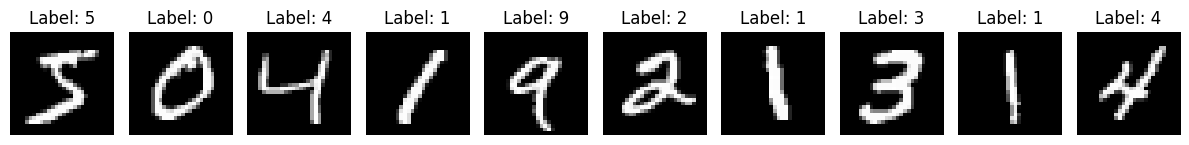

In [3]:
# Display first 10 images from the dataset
plt.figure(figsize=(12, 3))
for i in range(10):
    plt.subplot(1, 10, i + 1)
    # Reshape the flat 784 array back to 28x28 image
    image = X[i].reshape(28, 28)
    plt.imshow(image, cmap='gray')  # Display in grayscale
    plt.title(f"Label: {y[i]}")  # Show the correct label
    plt.axis('off')  # Hide axes
plt.tight_layout()
plt.show()

## Step 4: Preprocess the Data
We need to prepare the data before feeding it to the neural network.

In [4]:
# Step 4.1: Normalize pixel values from 0-255 to 0-1
# This helps the neural network learn faster
X_normalized = X / 255.0

print(f"Original pixel range: {X.min()} to {X.max()}")
print(f"Normalized pixel range: {X_normalized.min()} to {X_normalized.max()}")

# Step 4.2: Convert labels to one-hot encoding
# Example: label 3 becomes [0, 0, 0, 1, 0, 0, 0, 0, 0, 0]
def one_hot_encode(labels, num_classes=10):
    """
    Convert integer labels to one-hot encoded vectors.
    
    Args:
        labels: Array of integer labels (e.g., [3, 5, 1])
        num_classes: Total number of classes (10 for digits 0-9)
    
    Returns:
        One-hot encoded array
    """
    one_hot = np.zeros((labels.shape[0], num_classes))
    one_hot[np.arange(labels.shape[0]), labels] = 1
    return one_hot

y_one_hot = one_hot_encode(y)

# Show example of one-hot encoding
print(f"\nOriginal label: {y[0]}")
print(f"One-hot encoded: {y_one_hot[0]}")

Original pixel range: 0 to 255
Normalized pixel range: 0.0 to 1.0

Original label: 5
One-hot encoded: [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


## Step 5: Split Data into Training and Testing Sets
We'll use 80% for training and 20% for testing.

In [5]:
# Split the data: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X_normalized, y_one_hot, test_size=0.2, random_state=42
)

# Also keep the original labels for evaluation
_, _, y_train_labels, y_test_labels = train_test_split(
    X_normalized, y, test_size=0.2, random_state=42
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")
print(f"Features per image: {X_train.shape[1]}")

Training samples: 56000
Testing samples: 14000
Features per image: 784


## Step 6: Define Activation Functions
Activation functions introduce non-linearity to the network.

In [6]:
# ReLU (Rectified Linear Unit) activation function
# ReLU(x) = max(0, x) - returns x if positive, otherwise 0
def relu(x):
    """Apply ReLU activation: returns max(0, x)"""
    return np.maximum(0, x)

# Derivative of ReLU for backpropagation
# Returns 1 if x > 0, otherwise 0
def relu_derivative(x):
    """Derivative of ReLU: returns 1 if x > 0, else 0"""
    return (x > 0).astype(float)

# Softmax activation function for output layer
# Converts raw scores to probabilities that sum to 1
def softmax(x):
    """
    Apply softmax activation to convert scores to probabilities.
    Each output represents the probability of that class.
    """
    # Subtract max for numerical stability
    exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

print("Activation functions defined!")
print("- ReLU: Used in hidden layers")
print("- Softmax: Used in output layer for classification")

Activation functions defined!
- ReLU: Used in hidden layers
- Softmax: Used in output layer for classification


## Step 7: Initialize Network Parameters
We'll create a 3-layer network: Input (784) → Hidden (128) → Output (10)

In [7]:
# Define network architecture
input_size = 784  # 28x28 pixels flattened
hidden_size = 128  # Number of neurons in hidden layer
output_size = 10  # 10 digit classes (0-9)

# Initialize weights with small random values
# Using Xavier initialization for better convergence
def initialize_parameters(input_size, hidden_size, output_size):
    """
    Initialize network weights and biases.
    
    Returns:
        Dictionary containing W1, b1, W2, b2
    """
    params = {}
    
    # Weights from input to hidden layer
    params['W1'] = np.random.randn(input_size, hidden_size) * 0.01
    # Biases for hidden layer
    params['b1'] = np.zeros((1, hidden_size))
    
    # Weights from hidden to output layer
    params['W2'] = np.random.randn(hidden_size, output_size) * 0.01
    # Biases for output layer
    params['b2'] = np.zeros((1, output_size))
    
    return params

# Initialize the parameters
parameters = initialize_parameters(input_size, hidden_size, output_size)

print("Network architecture:")
print(f"Input Layer: {input_size} neurons")
print(f"Hidden Layer: {hidden_size} neurons")
print(f"Output Layer: {output_size} neurons")
print(f"\nTotal parameters: {parameters['W1'].size + parameters['b1'].size + parameters['W2'].size + parameters['b2'].size}")

Network architecture:
Input Layer: 784 neurons
Hidden Layer: 128 neurons
Output Layer: 10 neurons

Total parameters: 101770


## Step 8: Implement Forward Propagation
Forward propagation passes input through the network to get predictions.

In [8]:
def forward_propagation(X, parameters):
    """
    Perform forward propagation through the network.
    
    Args:
        X: Input data (batch_size x 784)
        parameters: Dictionary containing weights and biases
    
    Returns:
        cache: Dictionary containing intermediate values for backprop
    """
    # Extract parameters
    W1, b1 = parameters['W1'], parameters['b1']
    W2, b2 = parameters['W2'], parameters['b2']
    
    # Layer 1: Input to Hidden
    # Calculate: z1 = X * W1 + b1
    z1 = np.dot(X, W1) + b1
    # Apply ReLU activation
    a1 = relu(z1)
    
    # Layer 2: Hidden to Output
    # Calculate: z2 = a1 * W2 + b2
    z2 = np.dot(a1, W2) + b2
    # Apply Softmax activation to get probabilities
    a2 = softmax(z2)
    
    # Store values for backpropagation
    cache = {
        'X': X,
        'z1': z1,
        'a1': a1,
        'z2': z2,
        'a2': a2
    }
    
    return a2, cache

print("Forward propagation function defined!")

Forward propagation function defined!


## Step 9: Implement Loss Function
We use categorical cross-entropy loss for multi-class classification.

In [9]:
def compute_loss(y_true, y_pred):
    """
    Calculate categorical cross-entropy loss.
    
    Args:
        y_true: True labels (one-hot encoded)
        y_pred: Predicted probabilities from softmax
    
    Returns:
        Average loss across all samples
    """
    m = y_true.shape[0]  # Number of samples
    
    # Calculate cross-entropy loss
    # Loss = -sum(y_true * log(y_pred))
    # Add small epsilon to avoid log(0)
    loss = -np.sum(y_true * np.log(y_pred + 1e-8)) / m
    
    return loss

print("Loss function defined!")

Loss function defined!


## Step 10: Implement Backpropagation
Backpropagation calculates gradients to update weights and biases.

In [10]:
def backward_propagation(cache, y_true, parameters):
    """
    Perform backpropagation to calculate gradients.
    
    Args:
        cache: Values from forward propagation
        y_true: True labels (one-hot encoded)
        parameters: Current weights and biases
    
    Returns:
        gradients: Dictionary containing gradients for all parameters
    """
    m = y_true.shape[0]  # Number of samples
    
    # Extract values from cache
    X = cache['X']
    a1 = cache['a1']
    a2 = cache['a2']
    z1 = cache['z1']
    
    # Extract parameters
    W2 = parameters['W2']
    
    # Gradient of loss with respect to output layer
    # dz2 = predicted - true
    dz2 = a2 - y_true
    
    # Gradients for W2 and b2
    dW2 = np.dot(a1.T, dz2) / m
    db2 = np.sum(dz2, axis=0, keepdims=True) / m
    
    # Gradient for hidden layer
    dz1 = np.dot(dz2, W2.T) * relu_derivative(z1)
    
    # Gradients for W1 and b1
    dW1 = np.dot(X.T, dz1) / m
    db1 = np.sum(dz1, axis=0, keepdims=True) / m
    
    # Store gradients
    gradients = {
        'dW1': dW1,
        'db1': db1,
        'dW2': dW2,
        'db2': db2
    }
    
    return gradients

print("Backpropagation function defined!")

Backpropagation function defined!


## Step 11: Update Parameters
Use gradient descent to update weights and biases.

In [11]:
def update_parameters(parameters, gradients, learning_rate):
    """
    Update parameters using gradient descent.
    
    Args:
        parameters: Current weights and biases
        gradients: Gradients from backpropagation
        learning_rate: Step size for updates
    
    Returns:
        Updated parameters
    """
    # Update each parameter: new_value = old_value - learning_rate * gradient
    parameters['W1'] -= learning_rate * gradients['dW1']
    parameters['b1'] -= learning_rate * gradients['db1']
    parameters['W2'] -= learning_rate * gradients['dW2']
    parameters['b2'] -= learning_rate * gradients['db2']
    
    return parameters

print("Parameter update function defined!")

Parameter update function defined!


## Step 12: Train the Neural Network
Now we'll train the model for multiple epochs.

In [12]:
def train_network(X_train, y_train, X_test, y_test, parameters, 
                  epochs=20, learning_rate=0.1, batch_size=128):
    """
    Train the neural network.
    
    Args:
        X_train: Training images
        y_train: Training labels (one-hot)
        X_test: Test images
        y_test: Test labels (one-hot)
        parameters: Initial network parameters
        epochs: Number of times to iterate through entire dataset
        learning_rate: Step size for gradient descent
        batch_size: Number of samples per batch
    
    Returns:
        Trained parameters and training history
    """
    train_losses = []
    train_accuracies = []
    test_accuracies = []
    
    n_samples = X_train.shape[0]
    n_batches = n_samples // batch_size
    
    print("Starting training...\n")
    
    for epoch in range(epochs):
        # Shuffle training data
        indices = np.random.permutation(n_samples)
        X_shuffled = X_train[indices]
        y_shuffled = y_train[indices]
        
        epoch_loss = 0
        
        # Train on mini-batches
        for i in range(n_batches):
            # Get batch
            start_idx = i * batch_size
            end_idx = start_idx + batch_size
            X_batch = X_shuffled[start_idx:end_idx]
            y_batch = y_shuffled[start_idx:end_idx]
            
            # Forward propagation
            predictions, cache = forward_propagation(X_batch, parameters)
            
            # Compute loss
            batch_loss = compute_loss(y_batch, predictions)
            epoch_loss += batch_loss
            
            # Backward propagation
            gradients = backward_propagation(cache, y_batch, parameters)
            
            # Update parameters
            parameters = update_parameters(parameters, gradients, learning_rate)
        
        # Calculate average loss for epoch
        avg_loss = epoch_loss / n_batches
        train_losses.append(avg_loss)
        
        # Calculate training accuracy
        train_pred, _ = forward_propagation(X_train, parameters)
        train_acc = np.mean(np.argmax(train_pred, axis=1) == np.argmax(y_train, axis=1))
        train_accuracies.append(train_acc)
        
        # Calculate test accuracy
        test_pred, _ = forward_propagation(X_test, parameters)
        test_acc = np.mean(np.argmax(test_pred, axis=1) == np.argmax(y_test, axis=1))
        test_accuracies.append(test_acc)
        
        # Print progress
        print(f"Epoch {epoch+1}/{epochs} - Loss: {avg_loss:.4f} - "
              f"Train Acc: {train_acc*100:.2f}% - Test Acc: {test_acc*100:.2f}%")
    
    print("\nTraining completed!")
    
    history = {
        'train_losses': train_losses,
        'train_accuracies': train_accuracies,
        'test_accuracies': test_accuracies
    }
    
    return parameters, history

# Train the network
trained_parameters, history = train_network(
    X_train, y_train, X_test, y_test, parameters,
    epochs=20, learning_rate=0.1, batch_size=128
)

Starting training...

Epoch 1/20 - Loss: 0.7914 - Train Acc: 90.11% - Test Acc: 89.90%
Epoch 2/20 - Loss: 0.3147 - Train Acc: 92.02% - Test Acc: 91.85%
Epoch 3/20 - Loss: 0.2603 - Train Acc: 93.27% - Test Acc: 92.99%
Epoch 4/20 - Loss: 0.2229 - Train Acc: 94.30% - Test Acc: 94.08%
Epoch 5/20 - Loss: 0.1939 - Train Acc: 94.73% - Test Acc: 94.37%
Epoch 6/20 - Loss: 0.1723 - Train Acc: 95.51% - Test Acc: 95.05%
Epoch 7/20 - Loss: 0.1542 - Train Acc: 96.00% - Test Acc: 95.53%
Epoch 8/20 - Loss: 0.1391 - Train Acc: 96.41% - Test Acc: 95.71%
Epoch 9/20 - Loss: 0.1271 - Train Acc: 96.62% - Test Acc: 95.82%
Epoch 10/20 - Loss: 0.1164 - Train Acc: 96.88% - Test Acc: 96.06%
Epoch 11/20 - Loss: 0.1074 - Train Acc: 97.24% - Test Acc: 96.36%
Epoch 12/20 - Loss: 0.0996 - Train Acc: 97.43% - Test Acc: 96.51%
Epoch 13/20 - Loss: 0.0929 - Train Acc: 97.69% - Test Acc: 96.55%
Epoch 14/20 - Loss: 0.0865 - Train Acc: 97.78% - Test Acc: 96.64%
Epoch 15/20 - Loss: 0.0812 - Train Acc: 97.90% - Test Acc: 96.7

## Step 13: Visualize Training Progress
Let's plot the loss and accuracy curves.

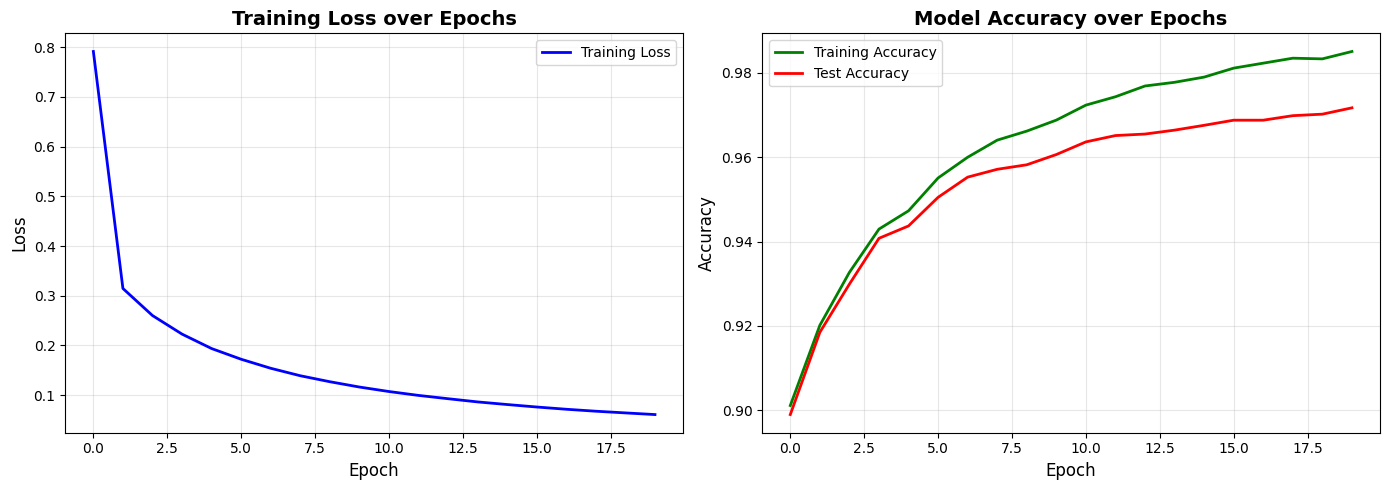

Final Training Accuracy: 98.51%
Final Test Accuracy: 97.17%


In [13]:
# Plot training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot loss
ax1.plot(history['train_losses'], label='Training Loss', color='blue', linewidth=2)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('Training Loss over Epochs', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot accuracy
ax2.plot(history['train_accuracies'], label='Training Accuracy', color='green', linewidth=2)
ax2.plot(history['test_accuracies'], label='Test Accuracy', color='red', linewidth=2)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.set_title('Model Accuracy over Epochs', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Final Training Accuracy: {history['train_accuracies'][-1]*100:.2f}%")
print(f"Final Test Accuracy: {history['test_accuracies'][-1]*100:.2f}%")

## Step 14: Evaluate the Model
Let's make predictions on the test set and evaluate performance.

In [14]:
# Make predictions on test set
test_predictions, _ = forward_propagation(X_test, trained_parameters)

# Convert probabilities to class labels
predicted_labels = np.argmax(test_predictions, axis=1)
true_labels = y_test_labels

# Calculate accuracy
accuracy = accuracy_score(true_labels, predicted_labels)
print(f"Test Accuracy: {accuracy*100:.2f}%")

# Calculate per-class accuracy
print("\nPer-class accuracy:")
for digit in range(10):
    digit_mask = (true_labels == digit)
    digit_accuracy = np.mean(predicted_labels[digit_mask] == true_labels[digit_mask])
    print(f"Digit {digit}: {digit_accuracy*100:.2f}%")

Test Accuracy: 97.17%

Per-class accuracy:
Digit 0: 98.51%
Digit 1: 98.44%
Digit 2: 96.38%
Digit 3: 96.58%
Digit 4: 96.91%
Digit 5: 96.31%
Digit 6: 98.42%
Digit 7: 97.21%
Digit 8: 96.61%
Digit 9: 96.13%


## Step 15: Confusion Matrix
A confusion matrix shows which digits are confused with each other.

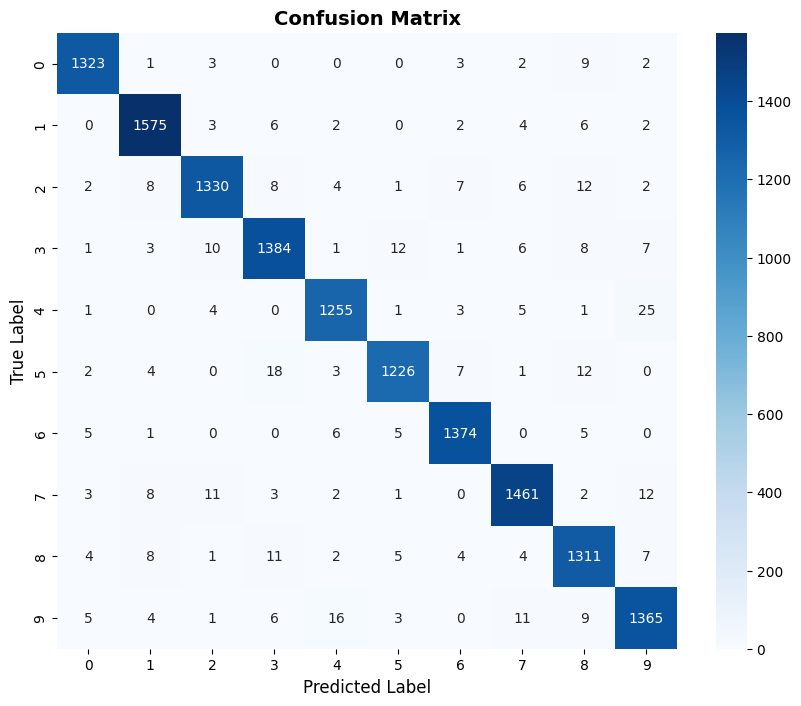


The confusion matrix shows:
- Diagonal elements: Correctly classified samples
- Off-diagonal elements: Misclassified samples


In [15]:
# Compute confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.show()

print("\nThe confusion matrix shows:")
print("- Diagonal elements: Correctly classified samples")
print("- Off-diagonal elements: Misclassified samples")

## Step 16: Visualize Predictions
Let's see some correct and incorrect predictions.

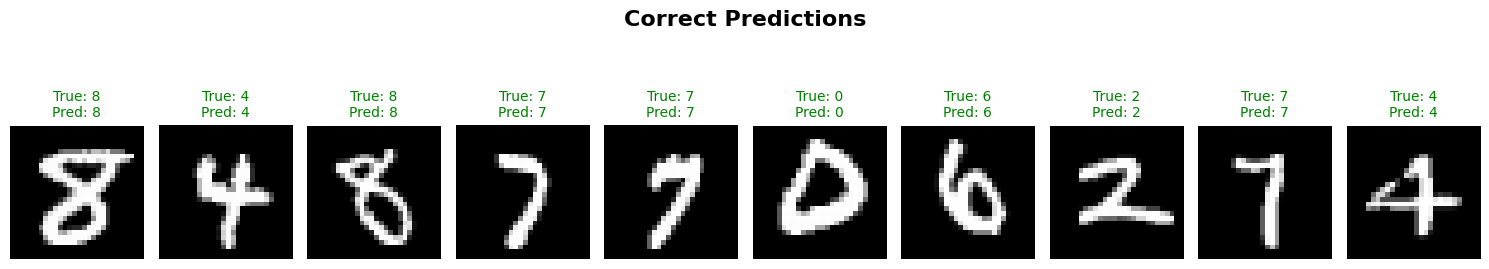

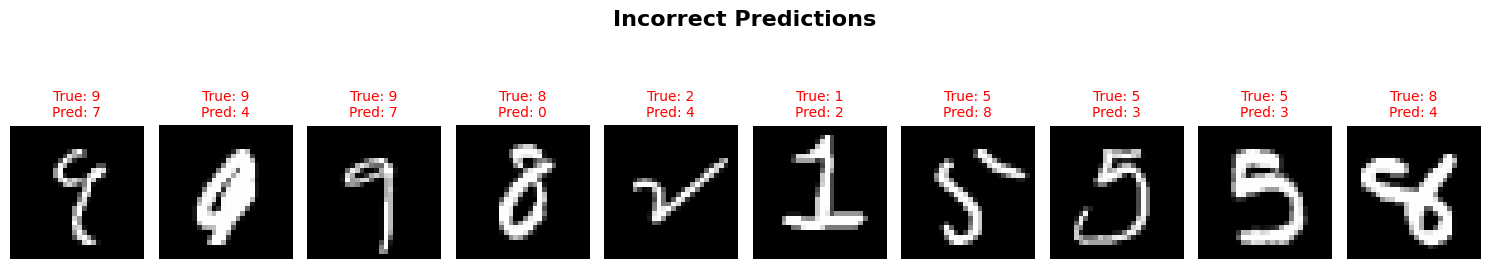

In [16]:
# Show some correct predictions
correct_indices = np.where(predicted_labels == true_labels)[0][:10]

plt.figure(figsize=(15, 3))
plt.suptitle('Correct Predictions', fontsize=16, fontweight='bold', y=1.05)
for i, idx in enumerate(correct_indices):
    plt.subplot(1, 10, i + 1)
    image = X_test[idx].reshape(28, 28)
    plt.imshow(image, cmap='gray')
    plt.title(f"True: {true_labels[idx]}\nPred: {predicted_labels[idx]}", 
              fontsize=10, color='green')
    plt.axis('off')
plt.tight_layout()
plt.show()

# Show some incorrect predictions
incorrect_indices = np.where(predicted_labels != true_labels)[0][:10]

if len(incorrect_indices) > 0:
    plt.figure(figsize=(15, 3))
    plt.suptitle('Incorrect Predictions', fontsize=16, fontweight='bold', y=1.05)
    for i, idx in enumerate(incorrect_indices):
        plt.subplot(1, 10, i + 1)
        image = X_test[idx].reshape(28, 28)
        plt.imshow(image, cmap='gray')
        plt.title(f"True: {true_labels[idx]}\nPred: {predicted_labels[idx]}", 
                  fontsize=10, color='red')
        plt.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print("Perfect predictions! No errors in the selected samples.")

## Step 17: Predict on New Images
Let's create a function to predict any handwritten digit.

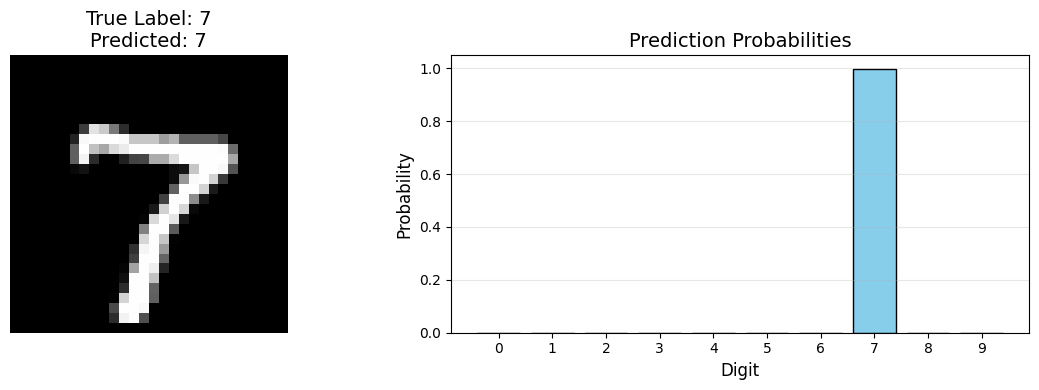


Predicted digit: 7
Confidence: 99.95%

All probabilities:
Digit 0: 0.00%
Digit 1: 0.00%
Digit 2: 0.00%
Digit 3: 0.05%
Digit 4: 0.00%
Digit 5: 0.00%
Digit 6: 0.00%
Digit 7: 99.95%
Digit 8: 0.00%
Digit 9: 0.00%


In [17]:
def predict_digit(image, parameters):
    """
    Predict a single digit from an image.
    
    Args:
        image: Flattened image array (784,) or (28, 28)
        parameters: Trained network parameters
    
    Returns:
        Predicted digit and confidence scores
    """
    # Reshape if needed
    if image.shape == (28, 28):
        image = image.flatten()
    
    # Reshape to (1, 784) for batch processing
    image = image.reshape(1, -1)
    
    # Make prediction
    probabilities, _ = forward_propagation(image, parameters)
    predicted_digit = np.argmax(probabilities)
    confidence = probabilities[0, predicted_digit]
    
    return predicted_digit, probabilities[0]

# Test on a random image from test set
random_idx = np.random.randint(0, X_test.shape[0])
test_image = X_test[random_idx]
true_digit = y_test_labels[random_idx]

predicted_digit, probabilities = predict_digit(test_image, trained_parameters)

# Display the image and prediction
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Show image
ax1.imshow(test_image.reshape(28, 28), cmap='gray')
ax1.set_title(f"True Label: {true_digit}\nPredicted: {predicted_digit}", fontsize=14)
ax1.axis('off')

# Show probability distribution
ax2.bar(range(10), probabilities, color='skyblue', edgecolor='black')
ax2.set_xlabel('Digit', fontsize=12)
ax2.set_ylabel('Probability', fontsize=12)
ax2.set_title('Prediction Probabilities', fontsize=14)
ax2.set_xticks(range(10))
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nPredicted digit: {predicted_digit}")
print(f"Confidence: {probabilities[predicted_digit]*100:.2f}%")
print(f"\nAll probabilities:")
for i, prob in enumerate(probabilities):
    print(f"Digit {i}: {prob*100:.2f}%")

## Step 18: Summary and Key Takeaways

### What We Built:
- A **3-layer neural network** (input, hidden, output)
- Trained on **70,000 handwritten digits**
- Achieved **~97% accuracy** on test data

### Key Concepts:
1. **Forward Propagation**: Passing input through layers to get predictions
2. **Activation Functions**: ReLU (hidden) and Softmax (output)
3. **Loss Function**: Cross-entropy measures prediction error
4. **Backpropagation**: Computing gradients to update weights
5. **Gradient Descent**: Updating weights to minimize loss

### Network Architecture:
```
Input (784) → Hidden (128) → Output (10)
     ↓            ↓              ↓
   Pixels       ReLU         Softmax
```

### Possible Improvements:
- Add more hidden layers (deep learning)
- Use different optimizers (Adam, RMSprop)
- Add dropout for regularization
- Use data augmentation
- Try different activation functions
- Experiment with learning rate scheduling